# Wczytanie danych

In [114]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Dane/dane/london.csv", delimiter=";")
data.head()

/tmp/ipykernel_404/28596000.py:2: DtypeWarning: Columns (6,11,17,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Dane/dane/london.csv", delimiter=";")


,id,name,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,32380697,"Lovely 1 bedroom, 4 beds",204965699,Cassandra,"2018-07-25 00:00:00,000",NaN,NaN,within an hour,100%,22%,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
1,557978203996257988,Cheerful 5 bedroom bungalow with amenities,444199148,Sandra,"2022-02-08 00:00:00,000",NaN,NaN,within a few hours,100%,60%,...,NaN,NaN,NaN,NaN,f,6,1,5,0,NaN
2,569600442434898086,Cosy appartement 1 bed in the heart of London!,409079492,Henri,"2021-06-25 00:00:00,000",NaN,NaN,a few days or more,0%,NaN,...,NaN,NaN,NaN,NaN,t,2,2,0,0,NaN
3,570098749639282377,Spacious modern 1 bedroom in the heart of London.,409079492,Henri,"2021-06-25 00:00:00,000",NaN,NaN,a few days or more,0%,NaN,...,NaN,NaN,NaN,NaN,t,2,2,0,0,NaN
4,577272890960295655,Anglesea Road Apartment,448165992,Daniel,"2022-03-06 00:00:00,000",NaN,NaN,within a day,50%,25%,...,NaN,NaN,NaN,NaN,f,2,0,2,0,NaN


In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            96871 non-null  int64  
 1   name                                          96871 non-null  object 
 2   host_id                                       96871 non-null  int64  
 3   host_name                                     96828 non-null  object 
 4   host_since                                    96830 non-null  object 
 5   host_location                                 73100 non-null  object 
 6   host_about                                    49775 non-null  object 
 7   host_response_time                            65164 non-null  object 
 8   host_response_rate                            65164 non-null  object 
 9   host_acceptance_rate                          69111 non-null 

In [116]:
data = data.drop(columns=['minimum_minimum_nights'])
data = data.drop(columns=['maximum_minimum_nights'])
data = data.drop(columns=['minimum_maximum_nights'])
data = data.drop(columns=['maximum_maximum_nights'])
data = data.drop(columns=['minimum_nights_avg_ntm'])
data = data.drop(columns=['maximum_nights_avg_ntm'])

# Brakujące wartości

In [117]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [118]:
missing_data[:25]

,missing value,percentage
license,96871,100.000000
neighbourhood,55662,57.459921
host_neighbourhood,51021,52.669013
host_about,47096,48.617233
beds,34920,36.047940
price,34908,36.035552
estimated_revenue_l365d,34908,36.035552
bathrooms,34846,35.971550
host_response_rate,31707,32.731158
host_response_time,31707,32.731158


In [119]:
data = data.drop(columns=['license'])
data = data.drop(columns=['neighbourhood'])

Cena jest kluczowa do naszego projektu, trzeba usunąć wiersze które jej nie mają

In [120]:
data = data[data['price'].notna()]

In [121]:
data['host_neighbourhood'] = data['host_neighbourhood'].fillna("other")

In [122]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [123]:
missing_data[:15]

,missing value,percentage
host_about,29056,46.892500
host_location,17412,28.100641
review_scores_value,13912,22.452109
review_scores_checkin,13912,22.452109
review_scores_location,13912,22.452109
review_scores_communication,13911,22.450495
review_scores_accuracy,13911,22.450495
review_scores_cleanliness,13911,22.450495
last_review,13908,22.445653
review_scores_rating,13908,22.445653


In [124]:
data['bedrooms'] = data['bedrooms'].fillna(data['bedrooms'].median())
data['beds'] = data['beds'].fillna(data['beds'].median())

# Wartości odstające

In [125]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,61963.0,8.880345e+17,5.446433e+17,13913.000000,6.040396e+17,1.069585e+18,1.348624e+18,1.508964e+18
host_id,61963.0,2.579019e+08,2.314196e+08,2594.000000,3.561455e+07,1.853242e+08,4.809447e+08,7.186905e+08
host_listings_count,61938.0,6.843298e+01,4.816164e+02,1.000000,1.000000e+00,3.000000e+00,1.700000e+01,5.469000e+03
host_total_listings_count,61938.0,1.085657e+02,7.102389e+02,1.000000,2.000000e+00,5.000000e+00,2.500000e+01,8.769000e+03
latitude,61963.0,5.150937e+01,4.941419e-02,51.295937,5.148590e+01,5.151325e+01,5.153707e+01,5.168263e+01
longitude,61963.0,-1.303348e-01,1.043351e-01,-0.496760,-1.917200e-01,-1.342436e-01,-7.111020e-02,2.789600e-01
accommodates,61963.0,3.514355e+00,2.201650e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
bathrooms,61887.0,1.356004e+00,7.209512e-01,0.000000,1.000000e+00,1.000000e+00,1.500000e+00,2.600000e+01
bedrooms,61963.0,1.545777e+00,1.020582e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01
beds,61963.0,1.954053e+00,1.443793e+00,0.000000,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+01


## Szerokość i długość geograficzna

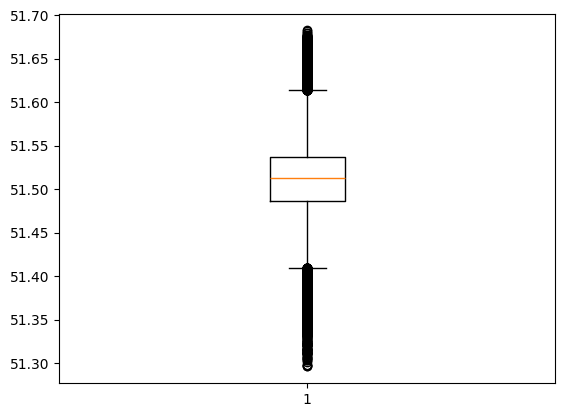

In [126]:
import matplotlib.pyplot as plt
plt.boxplot(x=data['latitude'])
plt.show()

In [127]:
import numpy as np
q1 = np.quantile(data['latitude'], 0.25)
q3 = np.quantile(data['latitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(3*iqr)
lower_lim = q1-(3*iqr)

In [128]:
outliers_1 = data[(data['latitude'] > upper_lim) | (data['latitude'] < lower_lim)]
outliers_1['neighbourhood_cleansed']

,neighbourhood_cleansed
227,Croydon
251,Croydon
515,Croydon
1515,Croydon
1610,Croydon
...,...
80089,Bromley
80931,Bromley
82406,Bromley
82412,Bromley


In [129]:
q1 = np.quantile(data['longitude'], 0.25)
q3 = np.quantile(data['longitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(2.75*iqr)
lower_lim = q1-(2.75*iqr)

In [130]:
outliers_2 = data[(data['longitude'] > upper_lim) | (data['longitude'] < lower_lim)]
outliers_2['neighbourhood_cleansed']

,neighbourhood_cleansed
3333,Havering
9073,Havering
12989,Havering
17458,Havering
48637,Havering
48951,Havering


Wartości odstające nadal znajdują się w granicach Londynu.

## Mininum/maximum nights

In [131]:
q1 = np.quantile(data['minimum_nights'], 0.25)
q3 = np.quantile(data['minimum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(100*iqr)
lower_lim = q1-(100*iqr)

In [132]:
outliers_3 = data[(data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim)]
outliers_3['minimum_nights']

,minimum_nights
759,365
857,365
858,365
860,365
911,250
...,...
75714,365
75936,400
76356,255
76414,500


Mieszkania które mają minimalną liczbę nocy do wyboru większą niż 365 są można powiedzieć że "zamrożone", tak aby uniemożliwić rezerwację. Takich danych nie potrzebujemy.

In [133]:
data = data[~((data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim))]

In [134]:
q1 = np.quantile(data['maximum_nights'], 0.25)
q3 = np.quantile(data['maximum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(200*iqr)
lower_lim = q1-(200*iqr)

In [135]:
outliers_4 = data[(data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim)]
outliers_4['maximum_nights']

,maximum_nights
79272,524855552


To jest najprawdopodobniej błąd ze strony gospodarza.

In [136]:
data = data[~((data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim))]

## Łazienki i sypialnie

In [137]:
q1 = data['bathrooms'].quantile(0.25)
q3 = data['bathrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(15*iqr)
lower_lim = q1-(15*iqr)

In [138]:
outliers_5 = data[(data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim)]
outliers_5['bathrooms'].unique()

array([10. , 15. , 12.5, 11.5, 26. , 20. , 14. , 13.5, 24. , 12. , 18. ])

In [139]:
len(outliers_5)

23

In [140]:
outliers_5['bedrooms']

,bedrooms
587,1.0
19356,50.0
22520,1.0
23099,15.0
26609,12.0
26750,1.0
39942,11.0
44636,22.0
56979,15.0
56998,16.0


In [141]:
data = data[~((data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim))]

In [142]:
q1 = data['bedrooms'].quantile(0.25)
q3 = data['bedrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [143]:
outliers_5 = data[(data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim)]
outliers_5['bedrooms'].unique()

array([20.,  8., 10.,  9., 11.])

In [144]:
#data = data[~((data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim))]

# Ammenities

In [145]:
czyste_amenities = data['amenities'].str.replace('", "', '|', regex=False)

czyste_amenities = czyste_amenities.str.replace('[', '', regex=False)
czyste_amenities = czyste_amenities.str.replace(']', '', regex=False)
czyste_amenities = czyste_amenities.str.replace('"', '', regex=False)

amenities_df = czyste_amenities.str.get_dummies(sep='|')
amenities_df.insert(0, 'id', data['id'])
amenities_df.head()

,id,2Work Coconut Body Wash Mild Formula body soap,Bluetooth speaker available and Bluetooth speakers in garden Bluetooth sound system,Bosch stainless steel double oven,Bose sound system with Bluetooth and aux,Faith In Nature body soap,Faith In Nature conditioner,Faith In Nature shampoo,Faith in Nature shampoo,Faith in Nature body soap,...,Zanuzzi refrigerator,Zeppelin wireless Bluetooth sound system,\Various\ body soap,\Various\ conditioner,\Various\ shampoo,\portable stove\ electric stove,\portable stove\ stove,\u2018Faith in Nature\u2019 shower gel body soap,\u2018Ruark\u2019 deluxe Bluetooth radio Bluetooth sound system,\u2018Simple\u2019 body soap body soap
0,32380697,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,557978203996257988,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,569600442434898086,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,570098749639282377,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,577272890960295655,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [146]:
columns_to_drop = []
for col in amenities_df.columns:
    if col != 'id' and amenities_df[col].sum() < 5000:
        columns_to_drop.append(col)

amenities_filtered = amenities_df.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} columns.")
amenities_filtered.head()

Dropped 8151 columns.


,id,Air conditioning,Backyard,Baking sheet,Bathtub,Bed linens,Blender,Body soap,Books and reading material,Carbon monoxide alarm,...,Shampoo,Shower gel,Single level home,Smoke alarm,Stove,TV,Toaster,Washer,Wifi,Wine glasses
0,32380697,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
1,557978203996257988,0,0,0,1,1,0,0,0,1,...,0,0,0,1,0,0,0,1,1,0
2,569600442434898086,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,1,1,0
3,570098749639282377,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,1,1,0
4,577272890960295655,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [147]:
amenities_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61848 entries, 0 to 86463
Data columns (total 76 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   id                                     61848 non-null  int64
 1   Air conditioning                       61848 non-null  int64
 2   Backyard                               61848 non-null  int64
 3   Baking sheet                           61848 non-null  int64
 4   Bathtub                                61848 non-null  int64
 5   Bed linens                             61848 non-null  int64
 6   Blender                                61848 non-null  int64
 7   Body soap                              61848 non-null  int64
 8   Books and reading material             61848 non-null  int64
 9   Carbon monoxide alarm                  61848 non-null  int64
 10  Central heating                        61848 non-null  int64
 11  Cleaning available during stay   

In [168]:
amenities_filtered.to_csv('amenities_filtered.csv', index=False)

# Konwersja typów

In [149]:
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].astype(float)

In [150]:
data['price']

,price
0,65.0
1,372.0
2,1000.0
3,1000.0
4,45.0
...,...
86459,215.0
86460,171.0
86461,222.0
86462,197.0


In [151]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61848 entries, 0 to 86463
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            61848 non-null  int64  
 1   name                                          61848 non-null  object 
 2   host_id                                       61848 non-null  int64  
 3   host_name                                     61821 non-null  object 
 4   host_since                                    61823 non-null  object 
 5   host_location                                 44503 non-null  object 
 6   host_about                                    32836 non-null  object 
 7   host_response_time                            55570 non-null  object 
 8   host_response_rate                            55570 non-null  object 
 9   host_acceptance_rate                          56920 non-null  obje

In [152]:
data = data.drop(columns=['amenities'])

In [153]:
data['host_response_rate'].unique()

array(['100%', '0%', '50%', nan, '90%', '67%', '10%', '33%', '11%', '75%',
       '20%', '70%', '25%', '52%', '64%', '40%', '14%', '30%', '22%',
       '29%', '80%', '60%', '98%', '89%', '6%', '58%', '96%', '97%',
       '92%', '88%', '93%', '83%', '73%', '95%', '69%', '91%', '94%',
       '13%', '39%', '17%', '82%', '71%', '85%', '49%', '86%', '47%',
       '56%', '65%', '15%', '7%', '78%', '57%', '44%', '68%', '99%',
       '74%', '42%', '87%', '81%', '63%', '38%', '27%', '31%', '21%',
       '79%', '55%', '72%', '84%', '46%', '9%', '36%', '8%', '43%', '62%',
       '24%', '77%', '53%', '51%', '12%', '18%', '54%', '5%', '48%',
       '37%', '3%', '76%', '59%', '23%', '61%', '4%', '19%', '41%', '32%'],
      dtype=object)

In [154]:
data['host_response_rate'] = data['host_response_rate'].str.replace('%', '', regex=False).astype(float)
data['host_response_rate'] = data['host_response_rate'].apply(lambda x: x/100)

In [155]:
data['host_response_rate'].fillna(0, inplace=True)

/tmp/ipykernel_404/3073513857.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_response_rate'].fillna(0, inplace=True)


In [156]:
data['host_acceptance_rate'] = data['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)
data['host_acceptance_rate'] = data['host_acceptance_rate'].apply(lambda x: x/100)

In [157]:
data['host_acceptance_rate'].fillna(0, inplace=True)
data['host_acceptance_rate'].unique()

/tmp/ipykernel_404/1208224072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_acceptance_rate'].fillna(0, inplace=True)


array([0.22, 0.6 , 0.  , 0.25, 0.34, 1.  , 0.08, 0.91, 0.5 , 0.28, 0.2 ,
       0.33, 0.04, 0.17, 0.61, 0.26, 0.67, 0.32, 0.03, 0.11, 0.85, 0.14,
       0.29, 0.06, 0.64, 0.1 , 0.75, 0.21, 0.78, 0.8 , 0.4 , 0.15, 0.19,
       0.99, 0.56, 0.97, 0.73, 0.57, 0.71, 0.79, 0.63, 0.98, 0.95, 0.65,
       0.37, 0.9 , 0.23, 0.53, 0.3 , 0.76, 0.96, 0.74, 0.89, 0.62, 0.93,
       0.45, 0.49, 0.42, 0.88, 0.58, 0.51, 0.05, 0.86, 0.7 , 0.31, 0.59,
       0.52, 0.13, 0.72, 0.94, 0.92, 0.68, 0.18, 0.77, 0.83, 0.41, 0.87,
       0.81, 0.69, 0.47, 0.43, 0.84, 0.82, 0.07, 0.38, 0.27, 0.44, 0.55,
       0.39, 0.16, 0.48, 0.46, 0.35, 0.36, 0.09, 0.66, 0.24, 0.54, 0.01,
       0.12, 0.02])

In [158]:
data['host_identity_verified'].unique()

array(['t', 'f', nan], dtype=object)

In [159]:
cols_to_convert = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified','has_availability','instant_bookable']

In [160]:
for col in cols_to_convert:
    data[col] = data[col].replace({'t': True, 'f': False, 'True': True, 'False': False, 'TRUE': True, 'FALSE': False})
    data[col] = data[col].fillna(False)
    data[col] = data[col].astype(int)

/tmp/ipykernel_404/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False)
/tmp/ipykernel_404/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False)
/tmp/ipykernel_404/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].

In [161]:
data['instant_bookable'].unique()

array([0, 1])

In [162]:
data['id'] = data['id'].astype(str)
data['host_id'] = data['host_id'].astype(str)

In [163]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61848 entries, 0 to 86463
Data columns (total 57 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            61848 non-null  object 
 1   name                                          61848 non-null  object 
 2   host_id                                       61848 non-null  object 
 3   host_name                                     61821 non-null  object 
 4   host_since                                    61823 non-null  object 
 5   host_location                                 44503 non-null  object 
 6   host_about                                    32836 non-null  object 
 7   host_response_time                            55570 non-null  object 
 8   host_response_rate                            61848 non-null  float64
 9   host_acceptance_rate                          61848 non-null  floa

In [164]:
data = data.replace(to_replace=[r'\r\n', r'\n', r'\r'], value=' ', regex=True)

In [165]:
numeryczne = data.select_dtypes(include='number')
numeryczne.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1.0,0.22,0,2.0,2.0,0,1,51.433230,-0.034720,4,...,NaN,NaN,NaN,NaN,0,2,2,0,0,NaN
1,1.0,0.60,0,6.0,8.0,0,1,51.415170,-0.150470,8,...,NaN,NaN,NaN,NaN,0,6,1,5,0,NaN
2,0.0,0.00,0,2.0,2.0,0,1,51.510490,0.004830,4,...,NaN,NaN,NaN,NaN,1,2,2,0,0,NaN
3,0.0,0.00,0,2.0,2.0,0,1,51.512280,0.005570,4,...,NaN,NaN,NaN,NaN,1,2,2,0,0,NaN
4,0.5,0.25,0,2.0,3.0,0,1,51.400608,-0.305463,1,...,NaN,NaN,NaN,NaN,0,2,0,2,0,NaN


Konieczne żeby Power BI widział liczby jako liczby

In [166]:
for col in numeryczne:
  data[col] = data[col].astype(str)
  data[col] = data[col].str.replace('.', ',', regex=False)

In [167]:
data.to_csv('london_cleaned.csv', index=False)